# Option A: Tsunami Warning Reinforcement Learning

This notebook summarizes the locally scraped BMKG bulletin archive, the event-summary dataset used to seed a data-informed warning simulator, and the reinforcement-learning results for tsunami warning decision support.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
DATA = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
FIGS = ROOT / 'outputs' / 'figures'
event_summary = pd.read_csv(DATA / 'bmkg_event_summary_enriched.csv')
event_splits = pd.read_csv(TABLES / 'event_summary_with_splits.csv')
training_history = pd.read_csv(TABLES / 'training_history.csv')
evaluation_summary = pd.read_csv(TABLES / 'agent_evaluation_summary.csv')
evaluation_by_seed = pd.read_csv(TABLES / 'agent_evaluation_by_seed.csv')
experiment_configuration = pd.read_csv(TABLES / 'experiment_configuration.csv')
external_enrichment = pd.read_csv(DATA / 'external_enrichment_summary.csv')
synthetic_counts = pd.read_csv(TABLES / 'synthetic_train_label_counts.csv')
dp_policy = pd.read_csv(TABLES / 'dp_optimal_policy.csv')
event_summary.head()

,event_group_id,origin_time_utc,location_name,latitude,longitude,initial_magnitude,max_magnitude,initial_depth_km,final_depth_km,coastal_proximity_index,...,usgs_felt,usgs_status,usgs_place,usgs_url,usgs_match_minutes,usgs_match_km,data_source,is_synthetic,external_wave_proxy_m,external_deaths_total
0,20120411085800,2012-04-11T08:38:00+00:00,Off West Coast of Northern Sumatra,2.33,93.04,8.3,8.3,10.0,10.0,0.75,...,3311.0,reviewed,2012 Wharton Basin Earthquake,https://earthquake.usgs.gov/earthquakes/eventp...,0.612000,2.577053,bmkg,0,1.08,10.0
1,20120725113100,2012-07-25T11:20:00+00:00,SolomonIslands,-9.74,159.79,6.8,6.8,43.0,43.0,0.40,...,NaN,NaN,NaN,NaN,NaN,NaN,bmkg,0,NaN,NaN
2,20120814031100,2012-08-14T02:59:00+00:00,SeaofOkhotsk,49.59,145.10,7.2,7.2,498.0,498.0,0.50,...,NaN,NaN,NaN,NaN,NaN,NaN,bmkg,0,NaN,NaN
3,20120826151500,2012-08-26T15:05:00+00:00,NorthernMoluccaSea,2.20,126.92,6.8,6.8,88.0,88.0,0.55,...,19.0,reviewed,"140 km WNW of Tobelo, Indonesia",https://earthquake.usgs.gov/earthquakes/eventp...,0.618000,9.289199,bmkg,0,NaN,NaN
4,20120831125800,2012-08-31T12:47:00+00:00,Philippine Islands Region,10.49,126.92,7.7,7.7,90.0,90.0,0.35,...,287.0,reviewed,"89 km E of Sulangan, Philippines",https://earthquake.usgs.gov/earthquakes/eventp...,0.556333,47.156145,bmkg,0,0.15,1.0


## Data Backbone

The event catalog starts with BMKG InaTSP public bulletin pages and linked detail pages, then adds external enrichment from NOAA NCEI tsunami events and the USGS earthquake catalog. Training is further augmented with synthetic bootstrap scenarios generated only from the real training split. The simulator still does not try to reproduce full tsunami physics, but it now uses more than one official agency source to anchor earthquake characteristics and wave/runup proxies.

In [2]:
event_splits[['time_split', 'danger_label', 'event_group_id']].groupby(['time_split', 'danger_label']).count().rename(columns={'event_group_id': 'count'})

count
time_split danger_label           
test       confirmed_threat      8
           no_threat            37
           potential_threat     25
train      confirmed_threat     31
           no_threat           166
           potential_threat    109
validation confirmed_threat      6
           no_threat            35
           potential_threat     23

In [3]:
external_enrichment

,bmkg_event_count,noaa_catalog_count,usgs_catalog_count,noaa_matched_event_count,usgs_matched_event_count,bmkg_observed_wave_count,external_wave_proxy_count
0,440,364,308,17,119,3,17


In [4]:
synthetic_counts

,danger_label,count
0,confirmed_threat,31
1,no_threat,166
2,potential_threat,109


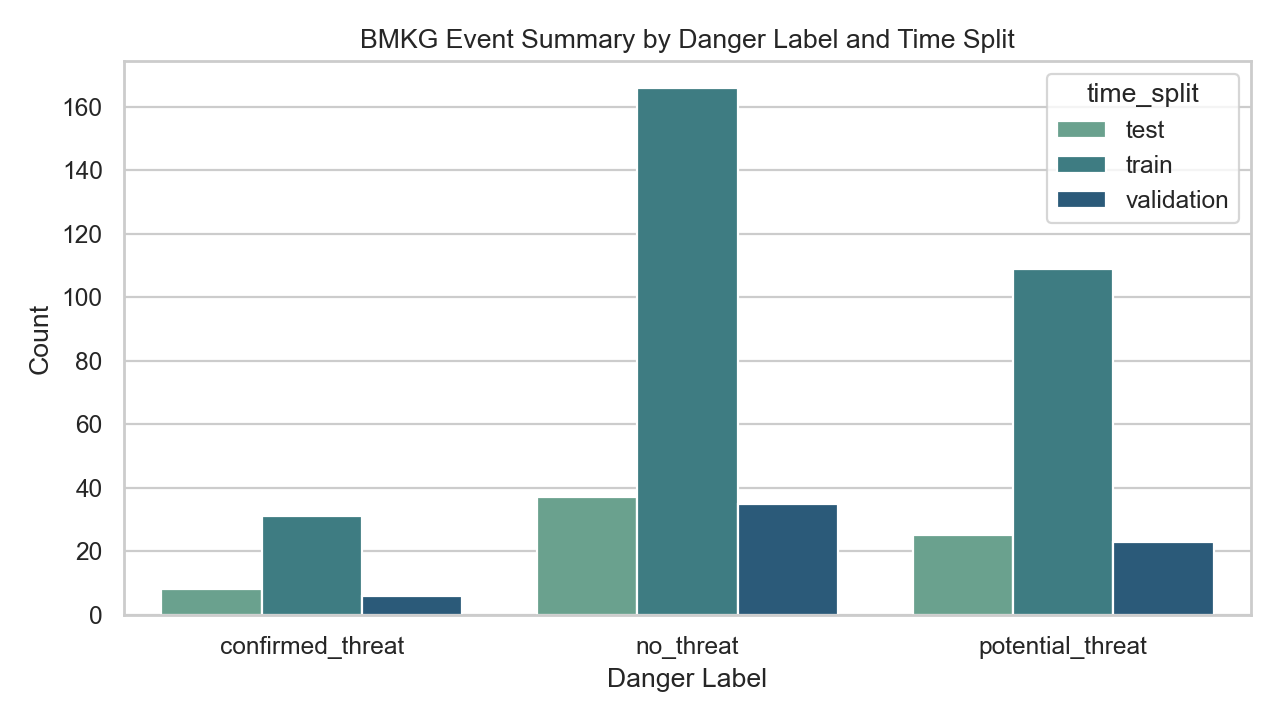

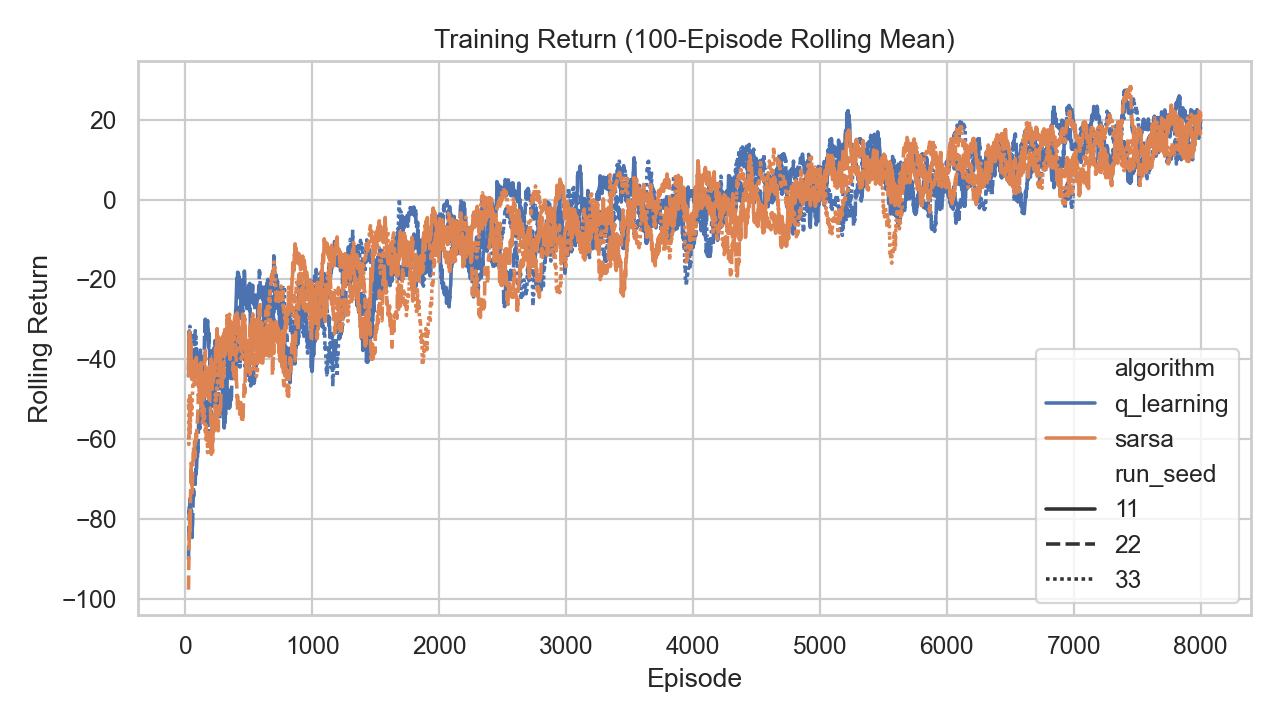

In [5]:
display(Image(filename=str(FIGS / 'danger_label_distribution.png')))
display(Image(filename=str(FIGS / 'training_returns.png')))

## Evaluation Snapshot

The main comparison here is between pure tabular SARSA/Q-learning policies, rule-backed safe SARSA/Q-learning policies, and a rule-based baseline on class-aware chronological validation and test splits. Each held-out event is evaluated once per seed. The dynamic-programming table is kept separately as a small fully observed oracle, not as a directly comparable baseline for the partially observed RL task.

In [6]:
evaluation_summary

,algorithm,split,runs,episode_count,no_threat_event_count,potential_event_count,severe_event_count,avg_return_mean,avg_return_ci95,median_return_mean,...,avg_alert_changes_mean,avg_alert_changes_ci95,avg_invalid_actions_mean,avg_invalid_actions_ci95,avg_warning_step_on_severe_mean,avg_warning_step_on_severe_ci95,avg_watch_step_on_potential_mean,avg_watch_step_on_potential_ci95,safety_score_mean,safety_score_ci95
0,q_learning_pure,validation,3,64,35,23,6,-0.522917,2.145833,13.800000,...,1.520833,0.132708,0.0,0.0,5.000000,0.748487,5.071011,0.327485,-100.999107,3.056794
1,q_learning_pure,test,3,70,37,25,8,-11.933333,0.765376,13.466667,...,1.638095,0.116946,0.0,0.0,4.250000,0.490000,4.590909,0.136089,-175.334234,23.344969
2,q_learning_safe,validation,3,64,35,23,6,20.242708,2.003273,13.800000,...,1.364583,0.171731,0.0,0.0,4.000000,0.000000,4.956522,0.000000,20.242708,2.003273
3,q_learning_safe,test,3,70,37,25,8,20.202381,0.341242,13.800000,...,1.471429,0.048497,0.0,0.0,3.875000,0.000000,4.933333,0.052267,20.202381,0.341242
4,sarsa_pure,validation,3,64,35,23,6,0.591667,1.722601,13.800000,...,1.562500,0.168669,0.0,0.0,5.000000,0.748487,4.827193,0.365500,-99.408333,1.722601
5,sarsa_pure,test,3,70,37,25,8,-7.171429,2.180782,13.716667,...,1.723810,0.056772,0.0,0.0,4.283333,0.117781,4.735178,0.196954,-133.072329,25.445990
6,sarsa_safe,validation,3,64,35,23,6,20.083854,1.271347,13.800000,...,1.380208,0.115042,0.0,0.0,4.000000,0.000000,4.956522,0.000000,20.083854,1.271347
7,sarsa_safe,test,3,70,37,25,8,20.171429,0.709088,13.800000,...,1.447619,0.093333,0.0,0.0,3.875000,0.000000,4.933333,0.052267,20.171429,0.709088
8,rule_based,validation,3,64,35,23,6,20.260938,1.624641,13.800000,...,1.328125,0.138096,0.0,0.0,3.944444,0.108889,4.913043,0.085217,20.260938,1.624641
9,rule_based,test,3,70,37,25,8,20.400000,0.259787,13.800000,...,1.438095,0.024694,0.0,0.0,3.875000,0.000000,4.960000,0.000000,20.400000,0.259787


In [7]:
experiment_configuration

,parameter,value
0,episodes,8000
1,alpha,0.08
2,gamma,0.985
3,epsilon_start,0.3
4,epsilon_end,0.02
5,rule_warm_start_episodes,500
6,warm_start_alpha,0.18
7,synthetic_training_multiplier,1.0
8,real_train_event_count,306
9,synthetic_train_event_count,306


In [8]:
evaluation_by_seed.head(10)

,algorithm,split,run_seed,episode_count,no_threat_event_count,potential_event_count,severe_event_count,avg_return,median_return,severe_miss_rate,false_warning_rate,avg_alert_changes,avg_invalid_actions,avg_warning_step_on_severe,avg_watch_step_on_potential,safety_score
0,q_learning_pure,validation,11,64,35,23,6,-2.637500,13.8,0.333333,0.028571,1.406250,0.0,5.750,4.736842,-104.066071
1,q_learning_pure,test,11,70,37,25,8,-11.550000,13.8,0.625000,0.000000,1.757143,0.0,4.000,4.500000,-199.050000
2,q_learning_safe,validation,11,64,35,23,6,22.042188,13.8,0.000000,0.000000,1.234375,0.0,4.000,4.956522,22.042188
3,q_learning_safe,test,11,70,37,25,8,19.857143,13.8,0.000000,0.000000,1.514286,0.0,3.875,4.880000,19.857143
4,q_learning_pure,validation,22,64,35,23,6,1.026563,13.8,0.333333,0.000000,1.515625,0.0,4.500,5.238095,-98.973438
5,q_learning_pure,test,22,70,37,25,8,-11.535714,13.3,0.500000,0.000000,1.585714,0.0,4.750,4.727273,-161.535714
6,q_learning_safe,validation,22,64,35,23,6,18.503125,13.8,0.000000,0.000000,1.531250,0.0,4.000,4.956522,18.503125
7,q_learning_safe,test,22,70,37,25,8,20.414286,13.8,0.000000,0.000000,1.428571,0.0,3.875,4.960000,20.414286
8,q_learning_pure,validation,33,64,35,23,6,0.042187,13.8,0.333333,0.000000,1.640625,0.0,4.750,5.238095,-99.957813
9,q_learning_pure,test,33,70,37,25,8,-12.714286,13.3,0.500000,0.054054,1.571429,0.0,4.000,4.545455,-165.416988


In [9]:
dp_policy.head(15)

,time_index,danger_tier,current_alert,cancel_issued,recommended_action
0,0,0,monitor,False,escalate
1,0,0,monitor,True,escalate
2,0,0,info,False,hold
3,0,0,info,True,hold
4,0,0,watch,False,deescalate
5,0,0,watch,True,deescalate
6,0,0,advisory,False,deescalate
7,0,0,advisory,True,deescalate
8,0,0,warning,False,cancel
9,0,0,warning,True,cancel


## Pitch Summary

- **Environment:** a time-stepped tsunami warning simulator informed by BMKG bulletin history.
- **External enrichment:** NOAA NCEI tsunami records, USGS earthquake catalog matches, and synthetic train-only bootstrap scenarios.
- **Use case:** a decision-support agent for alerting, escalation, and cancellation.
- **Target:** learn the warning policy that minimizes missed dangerous events, false alarms, and delay.
- **Utility:** strong positive reward for correct early warnings, strong penalties for missed severe tsunamis and false warnings, plus smaller penalties for delay, invalid actions, and alert thrashing.
- **Concepts implemented:** MDP framing, Bellman value updates, a value-iteration oracle on a tiny toy MDP, episodic rollout evaluation, temporal-difference learning, SARSA, Q-learning, exploration vs exploitation, comparison against a rule-based baseline, and an optional rule-backed safe fallback for deployment.
- **Limits:** the simulator is data-informed but still heuristic, especially for wave evolution, and the RL baselines are tabular rather than deep.